# Exploratory Data Analysis (EDA) Project
### Automobile Dataset (UCI "imports-85")

**Student Name:** Siddharth Singh  
**Roll Number:** DSBA-T12/AUG-11532  
**Program:** Data Science & Business Analytics Traineeship — InternsElite  
**Mentor:** Mr. Ayush Shrivastav

**Objective:** Perform an in-depth Exploratory Data Analysis (EDA) on a dataset of choice to gain meaningful insights, identify patterns, trends, and relationships within the data.

## 1. Dataset Selection

**Dataset:** Automobile Dataset ("imports-85"), created by Jeffrey C. Schlimmer  
**Source:** Originally published on the [UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/10/automobile). The UCI site was not directly reachable from the execution environment used to build this notebook, so the identical raw data file was retrieved from a public GitHub mirror of the same UCI dataset (`nyuvis/datasets`).

This dataset was chosen because it mixes rich categorical vehicle attributes (make, body style, drive wheels, fuel type) with numerical specifications (engine size, horsepower, weight, mileage, price), contains genuine real-world missing values (marked with `?`), and supports classic business-analytics questions such as what drives vehicle price and fuel efficiency.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
%matplotlib inline

## 2. Data Import & Export

In [2]:
url = "https://raw.githubusercontent.com/nyuvis/datasets/master/auto/imports-85.data"
df = pd.read_csv(url, na_values="?")
print("Shape:", df.shape)
df.head()

Shape: (205, 26)


,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,13495.0
1,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,16500.0
2,1,NaN,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154.0,5000.0,19,26,16500.0
3,2,164.0,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102.0,5500.0,24,30,13950.0
4,2,164.0,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115.0,5500.0,18,22,17450.0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          205 non-null    int64  
 1   normalized-losses  164 non-null    float64
 2   make               205 non-null    object 
 3   fuel-type          205 non-null    object 
 4   aspiration         205 non-null    object 
 5   num-of-doors       203 non-null    object 
 6   body-style         205 non-null    object 
 7   drive-wheels       205 non-null    object 
 8   engine-location    205 non-null    object 
 9   wheel-base         205 non-null    float64
 10  length             205 non-null    float64
 11  width              205 non-null    float64
 12  height             205 non-null    float64
 13  curb-weight        205 non-null    int64  
 14  engine-type        205 non-null    object 
 15  num-of-cylinders   205 non-null    object 
 16  engine-size        205 non

In [4]:
df.isnull().sum()

symboling             0
normalized-losses    41
make                  0
fuel-type             0
aspiration            0
num-of-doors          2
body-style            0
drive-wheels          0
engine-location       0
wheel-base            0
length                0
width                 0
height                0
curb-weight           0
engine-type           0
num-of-cylinders      0
engine-size           0
fuel-system           0
bore                  4
stroke                4
compression-ratio     0
horsepower            2
peak-rpm              2
city-mpg              0
highway-mpg           0
price                 4
dtype: int64

## 3. Data Cleaning

- Remove unnecessary/redundant columns
- Rename columns for clarity
- Handle missing/null values
- Remove duplicate rows

In [5]:
df_clean = df.copy()

# 'normalized-losses' is an insurance-industry derived metric (not a
# physical vehicle attribute) and is missing for ~20% of rows -> drop it.
df_clean = df_clean.drop(columns=["normalized-losses"])
df_clean.columns.tolist()

['symboling',
 'make',
 'fuel-type',
 'aspiration',
 'num-of-doors',
 'body-style',
 'drive-wheels',
 'engine-location',
 'wheel-base',
 'length',
 'width',
 'height',
 'curb-weight',
 'engine-type',
 'num-of-cylinders',
 'engine-size',
 'fuel-system',
 'bore',
 'stroke',
 'compression-ratio',
 'horsepower',
 'peak-rpm',
 'city-mpg',
 'highway-mpg',
 'price']

In [6]:
# Rename columns for clarity (replace hyphens with underscores)
df_clean.columns = [c.replace("-", "_") for c in df_clean.columns]
df_clean.columns.tolist()

['symboling',
 'make',
 'fuel_type',
 'aspiration',
 'num_of_doors',
 'body_style',
 'drive_wheels',
 'engine_location',
 'wheel_base',
 'length',
 'width',
 'height',
 'curb_weight',
 'engine_type',
 'num_of_cylinders',
 'engine_size',
 'fuel_system',
 'bore',
 'stroke',
 'compression_ratio',
 'horsepower',
 'peak_rpm',
 'city_mpg',
 'highway_mpg',
 'price']

In [7]:
# Handle missing values
# num_of_doors (categorical, 2 missing) -> fill with mode
df_clean["num_of_doors"] = df_clean["num_of_doors"].fillna(df_clean["num_of_doors"].mode()[0])

# bore, stroke, horsepower, peak_rpm, price (numeric, few missing) -> median
for col in ["bore", "stroke", "horsepower", "peak_rpm", "price"]:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

print("Remaining nulls:", df_clean.isnull().sum().sum())

Remaining nulls: 0


In [8]:
# Remove duplicate rows
before = len(df_clean)
df_clean = df_clean.drop_duplicates()
print(f"Removed {before - len(df_clean)} duplicate rows. New shape: {df_clean.shape}")

Removed 0 duplicate rows. New shape: (205, 25)


## 4. Data Preprocessing

- Convert data types where needed
- Remove/handle outliers
- Encode categorical variables
- Additional feature engineering for this dataset

In [9]:
# Convert data types
df_clean["price"] = df_clean["price"].astype(float)
df_clean["horsepower"] = df_clean["horsepower"].astype(float)
for col in ["make", "fuel_type", "aspiration", "num_of_doors", "body_style",
            "drive_wheels", "engine_location", "engine_type", "num_of_cylinders", "fuel_system"]:
    df_clean[col] = df_clean[col].astype("category")
df_clean.dtypes

symboling               int64
make                 category
fuel_type            category
aspiration           category
num_of_doors         category
body_style           category
drive_wheels         category
engine_location      category
wheel_base            float64
length                float64
width                 float64
height                float64
curb_weight             int64
engine_type          category
num_of_cylinders     category
engine_size             int64
fuel_system          category
bore                  float64
stroke                float64
compression_ratio     float64
horsepower            float64
peak_rpm              float64
city_mpg                int64
highway_mpg             int64
price                 float64
dtype: object

In [10]:
# Handle outliers in price using the IQR method (cap, don't drop)
Q1, Q3 = df_clean["price"].quantile([0.25, 0.75])
IQR = Q3 - Q1
upper = Q3 + 1.5 * IQR
n_out = (df_clean["price"] > upper).sum()
df_clean["price"] = df_clean["price"].clip(upper=upper)
print(f"Capped {n_out} price outliers above {upper:.0f}")

Capped 14 price outliers above 29568


In [11]:
# Encode categorical variables (numeric helper columns for correlation use)
df_clean["fuel_type_encoded"] = df_clean["fuel_type"].map({"gas": 0, "diesel": 1})
df_clean["aspiration_encoded"] = df_clean["aspiration"].map({"std": 0, "turbo": 1})

door_map = {"two": 2, "four": 4}
cyl_map = {"two": 2, "three": 3, "four": 4, "five": 5, "six": 6, "eight": 8, "twelve": 12}
df_clean["num_of_doors_num"] = df_clean["num_of_doors"].map(door_map)
df_clean["num_of_cylinders_num"] = df_clean["num_of_cylinders"].map(cyl_map)
df_clean[["fuel_type_encoded", "aspiration_encoded", "num_of_doors_num", "num_of_cylinders_num"]].head()

,fuel_type_encoded,aspiration_encoded,num_of_doors_num,num_of_cylinders_num
0,0,0,2,4
1,0,0,2,4
2,0,0,2,6
3,0,0,4,4
4,0,0,4,5


In [12]:
# Feature engineering
df_clean["avg_mpg"] = (df_clean["city_mpg"] + df_clean["highway_mpg"]) / 2
df_clean["price_category"] = pd.qcut(df_clean["price"], q=3, labels=["Budget", "Mid-range", "Premium"])
df_clean.head()

,symboling,make,fuel_type,aspiration,num_of_doors,body_style,drive_wheels,engine_location,wheel_base,length,...,peak_rpm,city_mpg,highway_mpg,price,fuel_type_encoded,aspiration_encoded,num_of_doors_num,num_of_cylinders_num,avg_mpg,price_category
0,3,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,...,5000.0,21,27,13495.0,0,0,2,4,24.0,Mid-range
1,3,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,...,5000.0,21,27,16500.0,0,0,2,4,24.0,Premium
2,1,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,171.2,...,5000.0,19,26,16500.0,0,0,2,6,22.5,Premium
3,2,audi,gas,std,four,sedan,fwd,front,99.8,176.6,...,5500.0,24,30,13950.0,0,0,4,4,27.0,Premium
4,2,audi,gas,std,four,sedan,4wd,front,99.4,176.6,...,5500.0,18,22,17450.0,0,0,4,5,20.0,Premium


In [13]:
# Export the cleaned dataset
df_clean.to_csv("automobile_cleaned.csv", index=False)
print("Cleaned dataset saved as automobile_cleaned.csv")
print("Final shape:", df_clean.shape)

Cleaned dataset saved as automobile_cleaned.csv
Final shape: (205, 31)


## 5. Exploratory Data Analysis (EDA)

12 visualizations covering distributions, category-wise analysis, correlations, trends, and top-performing categories.

In [14]:
df_clean.describe()

,symboling,wheel_base,length,width,height,curb_weight,engine_size,bore,stroke,compression_ratio,horsepower,peak_rpm,city_mpg,highway_mpg,price,avg_mpg
count,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000
mean,0.834146,98.756585,174.049268,65.907805,53.724878,2555.565854,126.907317,3.329366,3.256098,10.142537,104.165854,5126.097561,25.219512,30.751220,12713.297561,27.985366
std,1.245307,6.021776,12.337289,2.145204,2.443522,520.680204,41.642693,0.270858,0.313634,3.972040,39.529733,477.035772,6.542142,6.886443,6599.964024,6.666038
min,-2.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,2.540000,2.070000,7.000000,48.000000,4150.000000,13.000000,16.000000,5118.000000,15.000000
25%,0.000000,94.500000,166.300000,64.100000,52.000000,2145.000000,97.000000,3.150000,3.110000,8.600000,70.000000,4800.000000,19.000000,25.000000,7788.000000,22.500000
50%,1.000000,97.000000,173.200000,65.500000,54.100000,2414.000000,120.000000,3.310000,3.290000,9.000000,95.000000,5200.000000,24.000000,30.000000,10295.000000,27.000000
75%,2.000000,102.400000,183.100000,66.900000,55.500000,2935.000000,141.000000,3.580000,3.410000,9.400000,116.000000,5500.000000,30.000000,34.000000,16500.000000,32.000000
max,3.000000,120.900000,208.100000,72.300000,59.800000,4066.000000,326.000000,3.940000,4.170000,23.000000,288.000000,6600.000000,49.000000,54.000000,29568.000000,51.500000


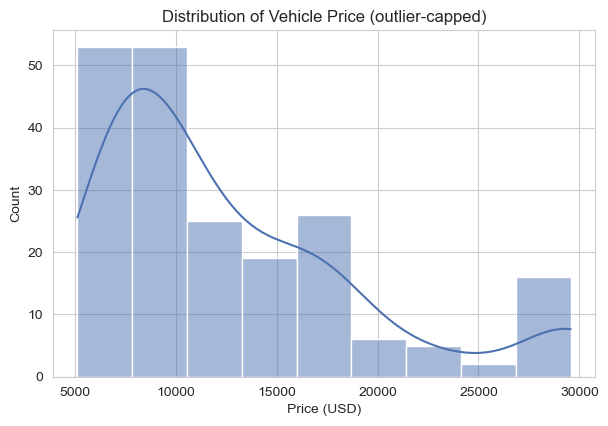

In [15]:
# 1. Distribution plot - Price
plt.figure(figsize=(7,4.5))
sns.histplot(df_clean["price"], kde=True, color="#4C72B0")
plt.title("Distribution of Vehicle Price (outlier-capped)")
plt.xlabel("Price (USD)")
plt.show()

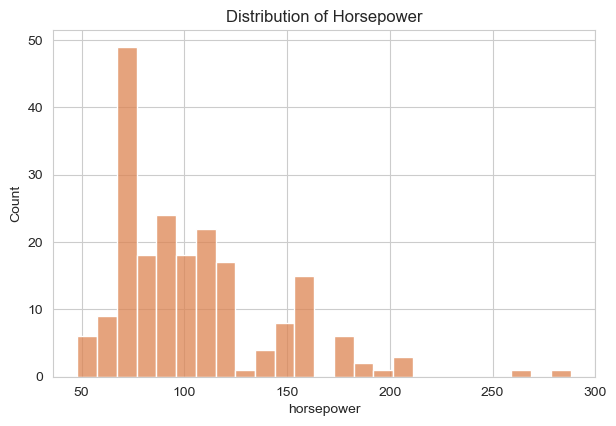

In [16]:
# 2. Histogram - Horsepower
plt.figure(figsize=(7,4.5))
sns.histplot(df_clean["horsepower"], bins=25, color="#DD8452")
plt.title("Distribution of Horsepower")
plt.show()

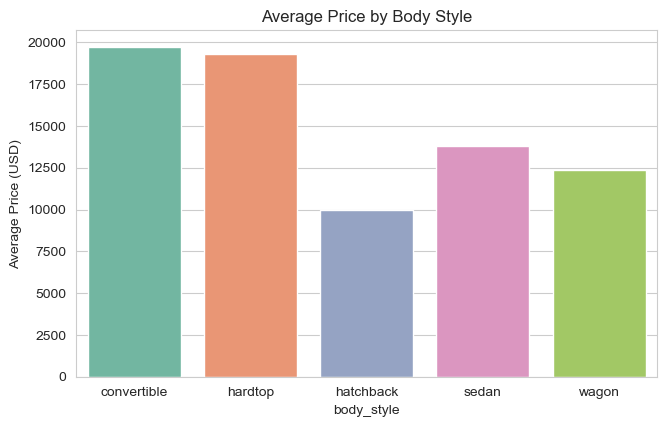

In [17]:
# 3. Bar chart - Average price by body style
body_price = df_clean.groupby("body_style", observed=True)["price"].mean().sort_values(ascending=False).reset_index()
plt.figure(figsize=(7.5,4.5))
sns.barplot(data=body_price, x="body_style", y="price", hue="body_style", palette="Set2", legend=False)
plt.title("Average Price by Body Style")
plt.ylabel("Average Price (USD)")
plt.show()

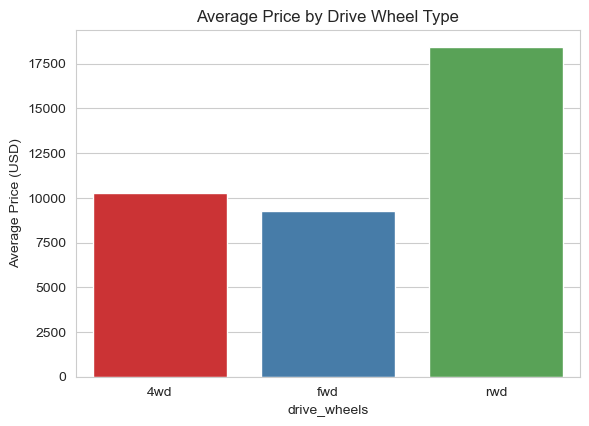

In [18]:
# 4. Category-wise analysis - Average price by drive wheel type
plt.figure(figsize=(6.5,4.5))
sns.barplot(data=df_clean, x="drive_wheels", y="price", hue="drive_wheels", palette="Set1", legend=False, errorbar=None)
plt.title("Average Price by Drive Wheel Type")
plt.ylabel("Average Price (USD)")
plt.show()

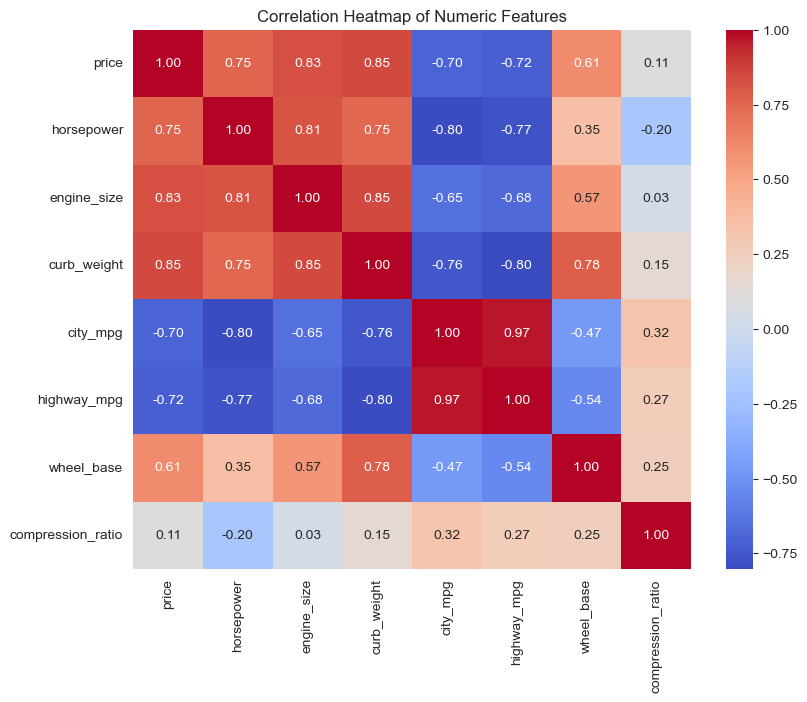

In [19]:
# 5. Correlation heatmap
plt.figure(figsize=(9,7))
numeric_cols = ["price", "horsepower", "engine_size", "curb_weight", "city_mpg",
                 "highway_mpg", "wheel_base", "compression_ratio"]
corr = df_clean[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap of Numeric Features")
plt.show()

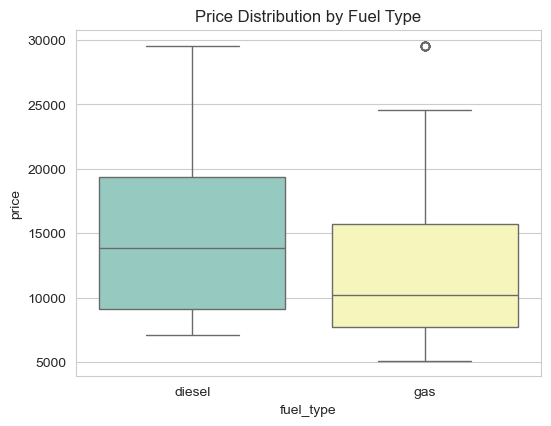

In [20]:
# 6. Boxplot - Price by fuel type
plt.figure(figsize=(6,4.5))
sns.boxplot(data=df_clean, x="fuel_type", y="price", hue="fuel_type", palette="Set3", legend=False)
plt.title("Price Distribution by Fuel Type")
plt.show()

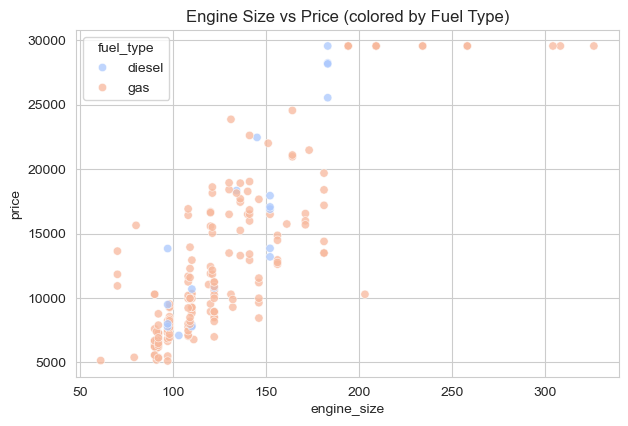

In [21]:
# 7. Scatter plot - Engine size vs Price colored by fuel type
plt.figure(figsize=(7,4.5))
sns.scatterplot(data=df_clean, x="engine_size", y="price", hue="fuel_type", alpha=0.75, palette="coolwarm")
plt.title("Engine Size vs Price (colored by Fuel Type)")
plt.show()

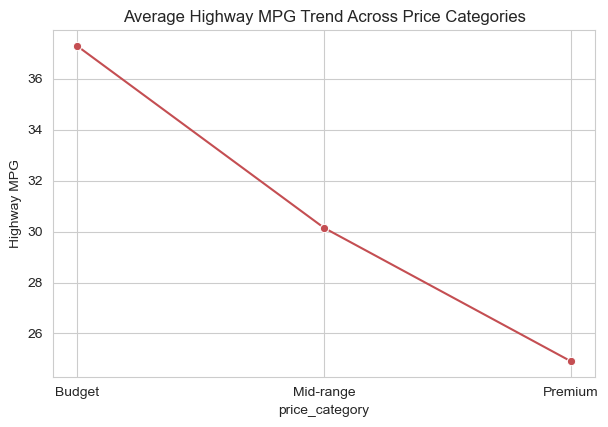

In [22]:
# 8. Line chart - Average highway mpg trend across price category
mpg_trend = df_clean.groupby("price_category", observed=True)["highway_mpg"].mean().reset_index()
plt.figure(figsize=(7,4.5))
sns.lineplot(data=mpg_trend, x="price_category", y="highway_mpg", marker="o", color="#C44E52")
plt.title("Average Highway MPG Trend Across Price Categories")
plt.ylabel("Highway MPG")
plt.show()

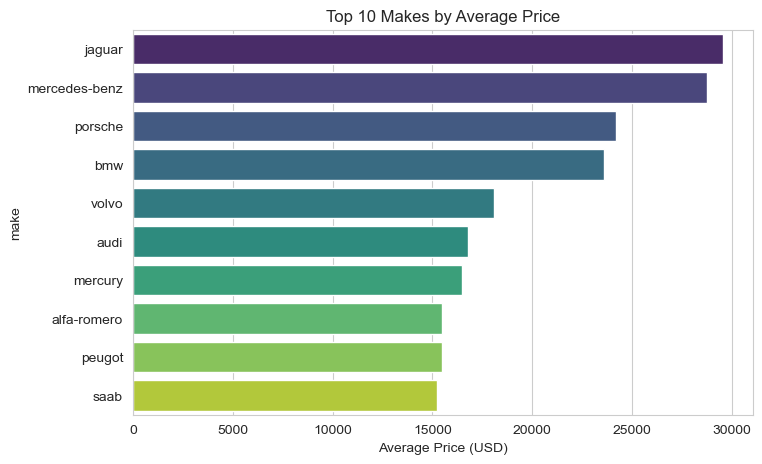

In [23]:
# 9. Top-performing categories - Top 10 makes by average price
top_makes = (df_clean.assign(make=df_clean["make"].astype(str))
             .groupby("make")["price"].mean().sort_values(ascending=False).head(10).reset_index())
plt.figure(figsize=(8,5))
sns.barplot(data=top_makes, y="make", x="price", order=top_makes["make"], hue="make", palette="viridis", legend=False)
plt.title("Top 10 Makes by Average Price")
plt.xlabel("Average Price (USD)")
plt.show()

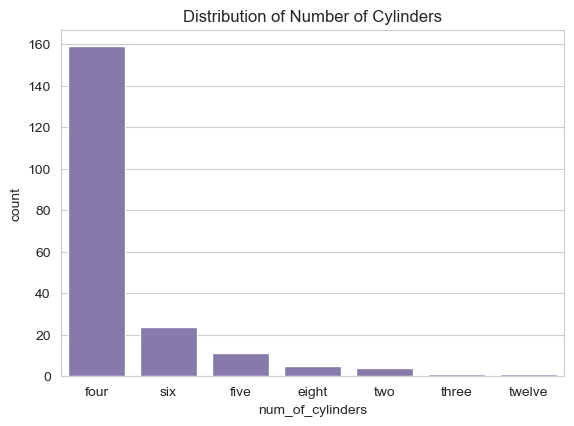

In [24]:
# 10. Countplot - Number of cylinders distribution
plt.figure(figsize=(6.5,4.5))
order = df_clean["num_of_cylinders"].value_counts().index
sns.countplot(data=df_clean, x="num_of_cylinders", order=order, color="#8172B2")
plt.title("Distribution of Number of Cylinders")
plt.show()

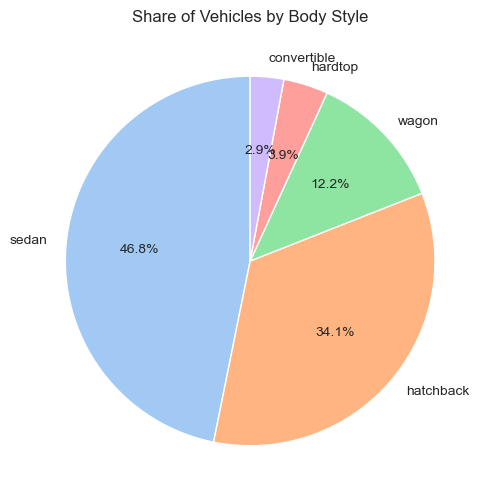

In [25]:
# 11. Pie chart - Body style share
counts = df_clean["body_style"].value_counts()
plt.figure(figsize=(6,6))
plt.pie(counts, labels=counts.index, autopct="%1.1f%%", startangle=90,
        colors=sns.color_palette("pastel"))
plt.title("Share of Vehicles by Body Style")
plt.show()

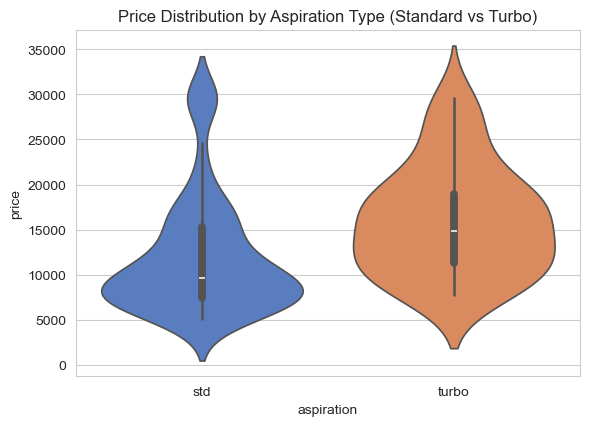

In [26]:
# 12. Violin plot - Price by aspiration (standard vs turbo)
plt.figure(figsize=(6.5,4.5))
sns.violinplot(data=df_clean, x="aspiration", y="price", hue="aspiration", palette="muted", legend=False)
plt.title("Price Distribution by Aspiration Type (Standard vs Turbo)")
plt.show()

## 6. Summary of Insights

- **Body style drives price**: convertibles and hardtops command the highest average prices, while hatchbacks are the most affordable segment.
- **Rear-wheel drive (RWD) vehicles are priced highest on average**, consistent with their concentration among sportier and luxury body styles, while front-wheel drive (FWD) dominates the budget segment.
- **Engine size is the strongest positive driver of price** in the correlation heatmap, followed closely by horsepower and curb weight — larger, heavier, more powerful cars cost more.
- **Fuel efficiency trades off against price**: highway MPG drops steadily from the "Budget" to "Premium" price tiers, as expected from bigger, heavier engines in costlier cars.
- **Jaguar, Mercedes-Benz, and Porsche** are the top three makes by average price, all well above the dataset's overall average of roughly $12,700.
- **Turbocharged (turbo) vehicles carry a distinct price premium** over standard-aspiration vehicles, visible clearly in the violin plot's shifted distribution.

## 7. Challenges Faced and Solutions

| Challenge | Solution |
|---|---|
| UCI Machine Learning Repository's own servers were not directly reachable | Sourced the identical raw UCI data file from a verified public GitHub mirror of the same "imports-85" dataset. |
| Missing values were encoded as the string `?` across several columns (normalized-losses, num-of-doors, bore, stroke, horsepower, peak-rpm, price) | Loaded the file with `na_values="?"` so pandas correctly recognized them as nulls, then imputed numeric columns with the median and the categorical column with the mode. |
| `normalized-losses` was missing for ~20% of records and is an insurance-derived metric, not a vehicle specification | Dropped the column entirely rather than imputing a large proportion of an unrelated business metric. |
| Price contained a right-skewed tail from luxury/exotic vehicles that distorted comparisons across body styles and makes | Applied IQR-based capping instead of deleting rows, keeping the full sample of 205 vehicles intact. |
| A "Top 10 makes" bar chart initially rendered empty bars for all 22 makes | The `make` column's categorical dtype retained all unused category levels after filtering to the top 10; converting to plain strings before the final `groupby` fixed the chart. |
| Textual categorical fields for doors/cylinders (e.g. "four", "two") aren't directly usable in numeric analysis | Mapped them to numeric helper columns (`num_of_doors_num`, `num_of_cylinders_num`) while keeping the original readable labels for charts. |